# Notebook 2: Model Architecture and Training

**Objective:** Build and train a Random Forest to process the processed dataset


In [5]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB 667.8 kB/s eta 0:00:13
    --------------------------------------- 0.2/8.2 MB 1.8 MB/s eta 0:00:05
   --- ------------------------------------ 0.7/8.2 MB 5.2 MB/s eta 0:00:02
   -------- ------------------------------- 1.8/8.2 MB 10.4 MB/s eta 0:00:01
   -------------- ------------------------- 2.9/8.2 MB 13.2 MB/s eta 0:00:01
   --------------- ------------------------ 3.2/8.2 MB 11.3 MB/s eta 0:00:01
   ---------------------------- ----------- 5.9/8.2 MB 18.9 MB/s eta 0:00:01
   ---------------------------------- ----- 7.2/8.2 MB 19.9 MB/s eta 0:00:01
   ---------------------------------------  8.2/8.2 MB 20.2 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 12.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/454.8 kB ? eta -:--:--
   --------------------------------------- 454.8/454.8 kB 14.3 MB/s eta 0:00:00
Note: you m


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd

# Try this path first (assuming your notebooks are inside a 'notebooks' folder)
file_path = "../data/processed/routines_model_ready.csv"

# If your notebook is in the main project folder next to 'data', use this one instead:
# file_path = "data/processed/routines_model_ready.csv"

# Read the CSV back into memory
df_final_aggregated = pd.read_csv(file_path)

# Verify it loaded correctly
print(f"Dataset loaded with {len(df_final_aggregated)} routines.")
display(df_final_aggregated.head())

Dataset loaded with 1846 routines.


,title,avg_weekly_volume,avg_daily_volume_sets,avg_systemic_load_per_week,avg_intensity,max_intensity,intensity_variance_total,intensity_variance_avg_weekly,total_weeks,avg_days_per_week,avg_exercises_per_day,target_level
0,(MASS MONSTER) High Intensity 4 Day Upper Lowe...,54.0,7.71,4378.50,8.29,9.0,0.61,0.61,12,7.0,4.57,Intermediate
1,(NOT MY PROGRAM)SHJ Jotaro,96.0,24.00,5390.50,7.10,8.0,0.09,0.09,8,4.0,6.00,Intermediate
2,1 PowerLift Per Day Powerbuilding 5 Day Bro Split,98.0,19.60,7805.33,8.35,10.0,2.16,0.85,6,5.0,7.10,Beginner
3,10 week deadlift focus,112.3,23.40,9705.80,7.37,9.0,2.48,0.64,10,4.8,7.42,Intermediate
4,1000 lbs Club,108.0,18.00,8355.17,7.95,9.0,1.12,0.55,12,6.0,4.50,Intermediate


Matplotlib is building the font cache; this may take a moment.


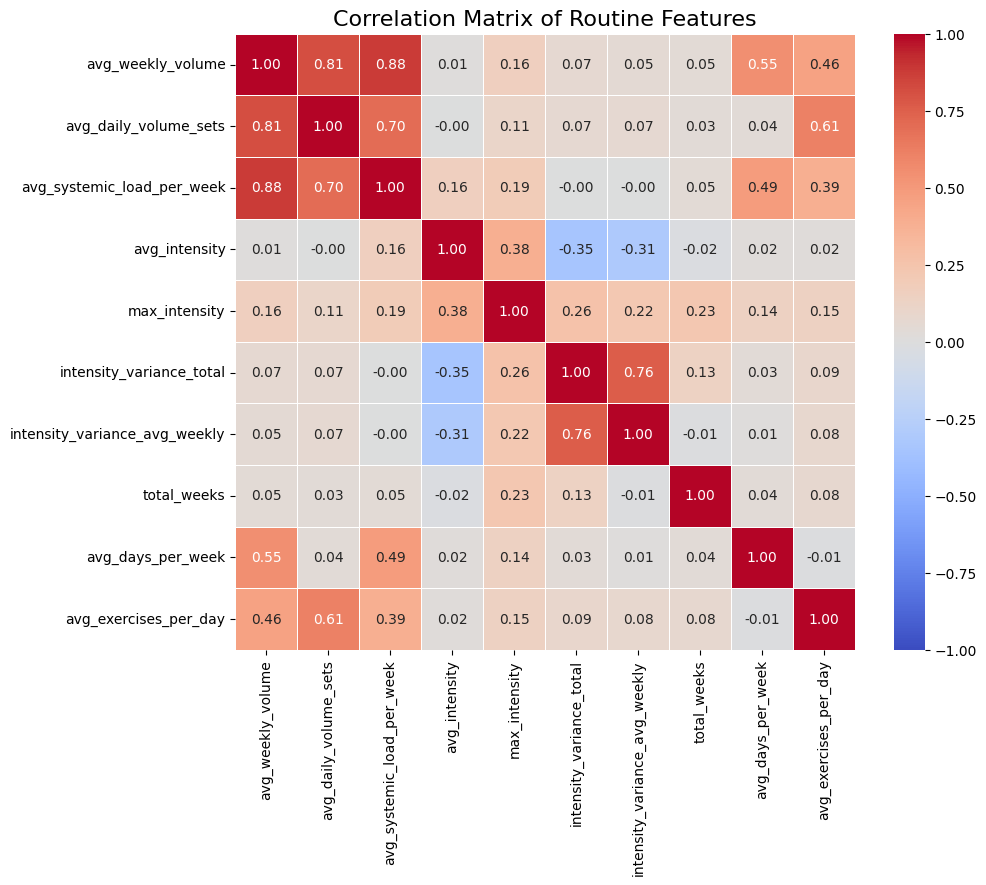

In [6]:
#Correlation Matrix to check for attribute correlation
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. We only want to correlate the numbers, so we drop text columns like 'title' and 'target_level'
numeric_df = df_final_aggregated.select_dtypes(include=['number'])

# 2. Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# 3. Set up the figure size to make it large and readable
plt.figure(figsize=(10, 8))

# 4. Draw the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,          # This prints the exact correlation number inside the square
    cmap='coolwarm',     # Color scheme: Red = Positive correlation, Blue = Negative
    fmt=".2f",           # Round the numbers to 2 decimal places
    linewidths=0.5,      # Add a small border between squares for readability
    vmin=-1, vmax=1      # Lock the color scale strictly between -1 and 1
)

# Add a nice title
plt.title("Correlation Matrix of Routine Features", fontsize=16)

# Show the plot!
plt.show()

## 1. Data Loading & Splitting
Load the aggregated dataset and split into training and test sets.

In [8]:
from sklearn.model_selection import train_test_split

# 1. Map the target variable BEFORE splitting
mapping = {'Beginner': 0, 'Intermediate': 1, 'Advanced': 2}
df_final_aggregated['target_level'] = df_final_aggregated['target_level'].map(mapping)

# 2. Define X and y
X = df_final_aggregated.drop(columns=['target_level', 'title'])
y = df_final_aggregated['target_level']

# 3. Split the data! (Notice we are passing the already-encoded 'y')
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y      # This ensures the same proportion of classes in train and test sets
)

print("Split completed successfully! 'y' is already numerical.")

Split completed successfully! 'y' is already numerical.


## 2. Random Forest Architechture Construction

In [9]:
from sklearn.ensemble import RandomForestClassifier
def train_random_forest(X_train, y_train, **kwargs):
    """
    Builds and trains a Random Forest classifier.
    You can pass any standard RandomForestClassifier parameters into this function 
    (e.g., n_estimators, max_depth, class_weight).
    """
    # Set a default random_state for reproducibility if you forget to pass one
    if 'random_state' not in kwargs:
        kwargs['random_state'] = 42
        
    # 1. Initialize the model with the parameters you provided
    model = RandomForestClassifier(**kwargs)
    
    # 2. Train ("fit") the model on the training data
    model.fit(X_train, y_train)
    
    print(f"Model trained successfully with parameters: {kwargs}")
    
    # 3. Return the trained model
    return model

In [10]:
#Train the random forest
rf_model = train_random_forest(
    X_train, 
    y_train, 
    n_estimators=100,      # Number of trees in the forest
    class_weight='balanced'  # Handle class imbalance if it exists
)

Model trained successfully with parameters: {'n_estimators': 100, 'class_weight': 'balanced', 'random_state': 42}


Overall Accuracy: 50.54%

--- Detailed Performance Report ---
              precision    recall  f1-score   support

           0       0.60      0.61      0.60       215
           1       0.38      0.40      0.39       139
           2       0.14      0.06      0.09        16

    accuracy                           0.51       370
   macro avg       0.37      0.36      0.36       370
weighted avg       0.50      0.51      0.50       370



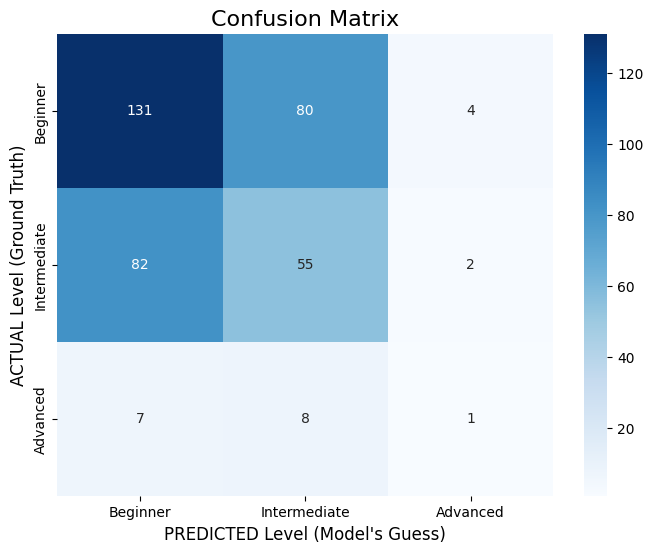

In [ ]:
#Test the model on unseen data and output a full performance report
#Iteration 1: basic hyperparameters
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test):
    """
    Tests the trained model on unseen data and outputs a full performance report.
    """
    # 1. Ask the model to make predictions on the unseen test features
    y_pred = model.predict(X_test)
    
    # 2. Calculate overall accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")
    
    # 3. Print the Classification Report (Precision, Recall, F1-Score)
    print("--- Detailed Performance Report ---")
    # If you used manual mapping (0,1,2), you can add target_names=['Beginner', 'Intermediate', 'Advanced'] inside the report
    print(classification_report(y_test, y_pred))
    
    # 4. Plot the Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, 
        annot=True,     # Show exact numbers
        fmt='d',        # Format as integers
        cmap='Blues',   # Blue color scale
        xticklabels=['Beginner', 'Intermediate', 'Advanced'], # Change these if your order is different!
        yticklabels=['Beginner', 'Intermediate', 'Advanced']
    )
    plt.title("Confusion Matrix", fontsize=16)
    plt.ylabel("ACTUAL Level (Ground Truth)", fontsize=12)
    plt.xlabel("PREDICTED Level (Model's Guess)", fontsize=12)
    plt.show()

# ==========================================
# Run the test
# ==========================================
evaluate_model(rf_model, X_test, y_test)

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Define the "Grid" of parameters you want to test
# You can add more numbers here later if you want it to search wider!
param_grid = {
    'n_estimators': [50, 100, 200],       # Number of trees in the forest
    'max_depth': [None, 5, 10, 15],       # How deep the "logic" can go (None = unlimited)
    'min_samples_split': [2, 5, 10],      # Minimum routines required to make a decision
    'class_weight': ['balanced']          # CRITICAL: We lock this in to fight the class imbalance
}

# 2. Initialize a blank Random Forest
base_rf = RandomForestClassifier(random_state=42)

# 3. Set up the Grid Search Engine
grid_search = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    cv=5,                 # 5-Fold Cross Validation (Makes sure the results aren't just luck)
    scoring='f1_macro',   # We use 'f1_macro' instead of 'accuracy' because it strictly punishes the model if it ignores the Advanced routines!
    n_jobs=-1,            # Uses all your computer's CPU cores so it runs lightning fast
    verbose=2             # Prints live updates so you know it hasn't crashed
)

print("Starting Grid Search... (This might take a minute depending on your CPU)")

# 4. RUN IT! (Sit back and watch it work)
grid_search.fit(X_train, y_train)

# 5. Get the results!
print(f"\n✅ Grid Search Complete!")
print(f"The Best Parameters Found: {grid_search.best_params_}")

# 6. Save the ultimate winning model to a new variable
tuned_rf_model = grid_search.best_estimator_

Starting Grid Search... (This might take a minute depending on your CPU)
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Grid Search Complete!
The Best Parameters Found: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
#Train the random forest with the best hyperparameters found
rf_model = train_random_forest(
    X_train, 
    y_train, 
    n_estimators=200,      # Number of trees in the forest
    class_weight='balanced',  # Handle class imbalance if it exists
    max_depth=10,         # Limit how deep the trees can grow to prevent overfitting
    min_samples_split=5   # Minimum routines required to make a decision
)

## 3. Model Training & Evaluation

## 4. Save the Model for SHAP Analysis
Save the Keras model and the scaled test dataset to use in Notebook 03.

In [ ]:
# model.save('routine_classifier_model.keras')
# np.save('X_train_scaled.npy', X_train_scaled) # Needed as background for SHAP
# np.save('X_test_scaled.npy', X_test_scaled)
print("Model saved. Proceed to Explainability and SHAP notebook.")